In [ ]:
"""
Plot frequency distribution of the DFR variable times of cirrus occurence without liquid in column.
Median value is then used as intercalibration offset between radars.

"""

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import sys
import pandas as pd
import scipy
import matplotlib as mpl

In [ ]:
# ---------------------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------------------
VARIABLE = "DFR_attcorr"
TIME_DIM = "time"
N_BINS = 50

In [ ]:
#final offset values
offset_v1_bef = 1.11
offset_v1_aft = -0.74
offset_v2_bef = 1.3
offset_v2_aft = 2.29

In [ ]:
# VAMPIRE-1
NC_FILE1 = f"VAMPIRE1_v1.1_level2_draco_20240813.nc"
NC_FILE2 = f"VAMPIRE1_v1.1_level2_draco_20240908.nc"
NC_FILE3 = f"VAMPIRE1_v1.1_level2_draco_20240909.nc"
NC_FILE4 = f"VAMPIRE1_v1.1_level2_draco_20240914.nc"
NC_FILE5 = f"VAMPIRE1_v1.1_level2_draco_20240925.nc"

LWC1 = f"PS144_uoc_hatpro_lhumpro-243-340_l2_clwvi_v01_20240813000000.nc"
LWC2 = f"PS144_uoc_hatpro_lhumpro-243-340_l2_clwvi_v01_20240908000000.nc"
LWC3 = f"PS144_uoc_hatpro_lhumpro-243-340_l2_clwvi_v01_20240909000000.nc"
LWC4 = f"PS144_uoc_hatpro_lhumpro-243-340_l2_clwvi_v01_20240914000000.nc"
LWC5 = f"PS144_uoc_hatpro_lhumpro-243-340_l2_clwvi_v01_20240925000000.nc"

START_TIME1, END_TIME1 = f"2024-08-13 16:00", f"2024-08-13 18:30"
START_TIME2, END_TIME2 = f"2024-09-08 11:30", f"2024-09-08 23:59"
START_TIME3, END_TIME3 = f"2024-09-09 00:00", f"2024-09-09 04:00"
START_TIME4, END_TIME4 = f"2024-09-14 12:30", f"2024-09-14 14:30"
START_TIME5, END_TIME5 = f"2024-09-25 19:40", f"2024-09-25 21:30"

"\nfor i in range(2, 6):\n    START_TIME = globals()['START_TIME' + str(i)]\n    END_TIME = globals()['END_TIME' + str(i)]\n    lwc[i] = xr.open_dataset(globals()['LWC' + str(i)]).sel({TIME_DIM: slice(START_TIME, END_TIME)})\n    lwc_sampled = lwc[i].sel(time=~lwc[i].indexes['time'].duplicated())\n    lwc_resampled = lwc_sampled.interp({TIME_DIM: ds_sub[i][TIME_DIM]})\n    dfr_values[i] = ds_sub[i].where((ds_sub[i]['tilt_flag'] < 1) & (lwc_resampled.clwvi < 0.01) , drop=True)[VARIABLE].values.flatten() #& (ds_sub[i]['WZe_attcorr'] < -15)\n    dfr_values[i] = dfr_values[i][~np.isnan(dfr_values[i])]\n"

In [ ]:

ds_sub, lwc, values = {}, {}, {}
for i in range(2, 6):
    NC_FILE = globals()['NC_FILE' + str(i)]
    START_TIME = globals()['START_TIME' + str(i)]
    END_TIME = globals()['END_TIME' + str(i)]
    ds = xr.open_dataset(NC_FILE)
    ds_sub[i] = ds.sel({TIME_DIM: slice(START_TIME, END_TIME)})
    ds_sub[i] = ds_sub[i].where((ds_sub[i]['tilt_flag'] < 1) , drop=True) 
    ds_sub[i]['case'] = (('time', 'height'), i * np.ones_like(ds_sub[i]['DFR']))  #add variable to identify which cirrus case data belongs to
    lwc[i] = xr.open_dataset(globals()['LWC' + str(i)]).sel({TIME_DIM: slice(START_TIME, END_TIME)})
    lwc_sampled = lwc[i].sel(time=~lwc[i].indexes['time'].duplicated())
    lwc_resampled = lwc_sampled.interp({TIME_DIM: ds_sub[i][TIME_DIM]})
    values[i] = ds_sub[i].where((ds_sub[i]['tilt_flag'] < 1) & (lwc_resampled.clwvi < 0.01) & (ds_sub[i]['WZe_attcorr']<-15), drop=True) 

'''
for i in range(2, 6):
    START_TIME = globals()['START_TIME' + str(i)]
    END_TIME = globals()['END_TIME' + str(i)]
    lwc[i] = xr.open_dataset(globals()['LWC' + str(i)]).sel({TIME_DIM: slice(START_TIME, END_TIME)})
    lwc_sampled = lwc[i].sel(time=~lwc[i].indexes['time'].duplicated())
    lwc_resampled = lwc_sampled.interp({TIME_DIM: ds_sub[i][TIME_DIM]})
    dfr_values[i] = ds_sub[i].where((ds_sub[i]['tilt_flag'] < 1) & (lwc_resampled.clwvi < 0.01) , drop=True)[VARIABLE].values.flatten() #& (ds_sub[i]['WZe_attcorr'] < -15)
    dfr_values[i] = dfr_values[i][~np.isnan(dfr_values[i])]
'''


In [ ]:
#VAMPIRE-1
ds_subset = xr.concat([ds_sub[i] for i in range(2, 6)], dim=TIME_DIM)
dfr_bef = np.concatenate([values[i][VARIABLE].values.flatten() for i in range(2, 4)])-offset_v1_bef
dfr_aft = np.concatenate([values[i][VARIABLE].values.flatten() for i in range(4, 6)])-offset_v1_aft
wze_bef = np.concatenate([values[i]['WZe_attcorr'].values.flatten() for i in range(2, 4)])
wze_aft = np.concatenate([values[i]['WZe_attcorr'].values.flatten() for i in range(4, 6)])
gze_bef = np.concatenate([values[i]['GZe_attcorr'].values.flatten() for i in range(2, 4)])+offset_v1_bef
gze_aft = np.concatenate([values[i]['GZe_attcorr'].values.flatten() for i in range(4, 6)])+offset_v1_aft

In [ ]:
lwc_before = xr.concat([lwc[i] for i in range(2, 4)], dim=TIME_DIM)
lwc_after = xr.concat([lwc[i] for i in range(4, 6)], dim=TIME_DIM)

In [ ]:
# VAMPIRE-2
NC_FILE1 = f"VAMPIRE2_v1.1_level2_draco_20250714.nc"
NC_FILE2 = f"VAMPIRE2_v1.1_level2_draco_20250722.nc"
NC_FILE3 = f"VAMPIRE2_v1.1_level2_draco_20250723.nc"
NC_FILE4 = f"VAMPIRE2_v1.1_level2_draco_20250729.nc"
NC_FILE5 = f"VAMPIRE2_v1.1_level2_draco_20250806.nc"
NC_FILE6 = f"VAMPIRE2_v1.1_level2_draco_20250818.nc"
LWC1 = f"PS149_uoc_hatpro_lhumpro-243-340_l2_clwvi_v01_20250714000000.nc"
LWC2 = f"PS149_uoc_hatpro_lhumpro-243-340_l2_clwvi_v01_20250722000000.nc"
LWC3 = f"PS149_uoc_hatpro_lhumpro-243-340_l2_clwvi_v01_20250723000000.nc"
LWC4 = f"PS149_uoc_hatpro_lhumpro-243-340_l2_clwvi_v01_20250729000000.nc"
LWC5 = f"PS149_uoc_hatpro_lhumpro-243-340_l2_clwvi_v01_20250806000000.nc"
LWC6 = f"PS149_uoc_hatpro_lhumpro-243-340_l2_clwvi_v01_20250818000000.nc"
START_TIME1, END_TIME1 = f"2025-07-14 09:00", f"2025-07-14 16:00"
START_TIME2, END_TIME2 = f"2025-07-22 10:00", f"2025-07-22 17:30"
START_TIME3, END_TIME3 = f"2025-07-23 03:00", f"2025-07-23 09:00"
START_TIME4, END_TIME4 = f"2025-07-29 11:00", f"2025-07-29 17:30"
START_TIME5, END_TIME5 = f"2025-08-06 18:00", f"2025-08-06 23:00"
START_TIME6, END_TIME6 = f"2025-08-18 05:00", f"2025-08-18 16:00"

ds_sub = {}
lwc = {}
for i in (1,2,4,5,6):
    NC_FILE = globals()['NC_FILE' + str(i)]
    START_TIME = globals()['START_TIME' + str(i)]
    END_TIME = globals()['END_TIME' + str(i)]
    ds = xr.open_dataset(NC_FILE)
    ds_sub[i] = ds.sel({TIME_DIM: slice(START_TIME, END_TIME)})
    ds_sub[i] = ds_sub[i].where((ds_sub[i]['tilt_flag'] < 1) , drop=True) #& (ds_sub[i]['WZe_attcorr'] < -15)
    #dfr_values[i] = ds_sub[i].where((ds_sub[i]['tilt_flag'] < 1) , drop=True)[VARIABLE].values.flatten() #& (ds_sub[i]['WZe_attcorr'] < -15)
    ds_sub[i]['case'] = (('time', 'height'), i * np.ones_like(ds_sub[i]['DFR']))  # Add a new coordinate to identify the case number
    lwc[i] = xr.open_dataset(globals()['LWC' + str(i)]).sel({TIME_DIM: slice(START_TIME, END_TIME)})
    lwc_sampled = lwc[i].sel(time=~lwc[i].indexes['time'].duplicated())
    lwc_resampled = lwc_sampled.interp({TIME_DIM: ds_sub[i][TIME_DIM]})
    values[i] = ds_sub[i].where((ds_sub[i]['tilt_flag'] < 1) & (lwc_resampled.clwvi < 0.01) & (ds_sub[i]['WZe_attcorr']<-15), drop=True)

i = 3
NC_FILE = globals()['NC_FILE' + str(i)]
START_TIME = globals()['START_TIME' + str(i)]
END_TIME = globals()['END_TIME' + str(i)]
ds = xr.open_dataset(NC_FILE)
ds_sub[i] = ds.sel({TIME_DIM: slice(START_TIME, END_TIME)})
ds_sub[i] = ds_sub[i].where((ds_sub[i]['tilt_flag'] < 1) , drop=True) #& (ds_sub[i]['WZe_attcorr'] < -15)
#dfr_values[i] = ds_sub[i].where((ds_sub[i]['tilt_flag'] < 1) , drop=True)[VARIABLE].values.flatten() #& (ds_sub[i]['WZe_attcorr'] < -15)
ds_sub[i]['case'] = (('time', 'height'), i * np.ones_like(ds_sub[i]['DFR']))  # Add a new coordinate to identify the case number
values[i] = ds_sub[i].where((ds_sub[i]['tilt_flag'] < 1) & (ds_sub[i]['WZe_attcorr']<-15), drop=True)

In [ ]:
#VAMPIRE-2
ds_subset = xr.concat([ds_sub[i] for i in range(1, 7)], dim=TIME_DIM)

dfr_bef = np.concatenate([values[i][VARIABLE].values.flatten() for i in range(1, 5)])-offset_v2_bef
dfr_aft = np.concatenate([values[i][VARIABLE].values.flatten() for i in range(5, 7)])-offset_v2_aft
wze_bef = np.concatenate([values[i]['WZe_attcorr'].values.flatten() for i in range(1, 5)])
wze_aft = np.concatenate([values[i]['WZe_attcorr'].values.flatten() for i in range(5, 7)])
gze_bef = np.concatenate([values[i]['GZe_attcorr'].values.flatten() for i in range(1, 5)])+offset_v2_bef
gze_aft = np.concatenate([values[i]['GZe_attcorr'].values.flatten() for i in range(5, 7)])+offset_v2_aft

In [ ]:
dfr_bef = dfr_bef[~np.isnan(dfr_bef)]
dfr_aft = dfr_aft[~np.isnan(dfr_aft)]

In [ ]:
OUTPUT_PLOT = f"VAMP1_all_dfr_distribution.png"
timeseries = f"VAMP1_all_dfr_timeseries.png"
WG_scatterplot = f"VAMP1_all_ZeW_ZeG_scatterplot.png"

In [ ]:
lwc_after = lwc_after.drop_duplicates(dim='time')
lwc_before = lwc_before.drop_duplicates(dim='time')
#dfr_aft = dfr_aft.drop_duplicates(dim='time')
#dfr_bef = dfr_bef.drop_duplicates(dim='time')

In [ ]:
number = 4

In [ ]:
# ---------------------------------------------------------------------
# Plot time series of DFR values with LWC overlay
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 6))
levels = np.linspace(-5, 10, 100)
plt.contourf(ds_sub[number][TIME_DIM], ds_sub[number]['height'], ds_sub[number]['DFR_attcorr'].T, cmap='viridis', levels=levels)
plt.title(f"Time series of {VARIABLE} from {START_TIME} to {END_TIME}")
plt.xlabel(f"Time")
plt.xticks(rotation=45)

plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
plt.ylabel("Height (m)")
colorbar = plt.colorbar(label=f"{VARIABLE} (dBZ)")
plt.grid(axis='y', alpha=0.75)

# Overlay LWC data with second y-axis
lwp = plt.twinx()
plt.ylabel("LWC (kg/m²)")
plt.plot(lwc_sampled[TIME_DIM], lwc_sampled['clwvi'], label=f'LWP', marker='.', linestyle='None', markersize=3)
plt.ylim(0, 0.25)
plt.hlines(y=0.02, xmin=ds_sub[number][TIME_DIM].min(), xmax=ds_sub[number][TIME_DIM].max(), color='k', linestyle='--', linewidth=0.5)
plt.legend()
# add space between the second y-axis and the colorbar to avoid overlap
plt.subplots_adjust(right=1.75)
#plt.tight_layout()


plt.savefig(timeseries, bbox_inches='tight')
print(f"Time series saved to {timeseries}")

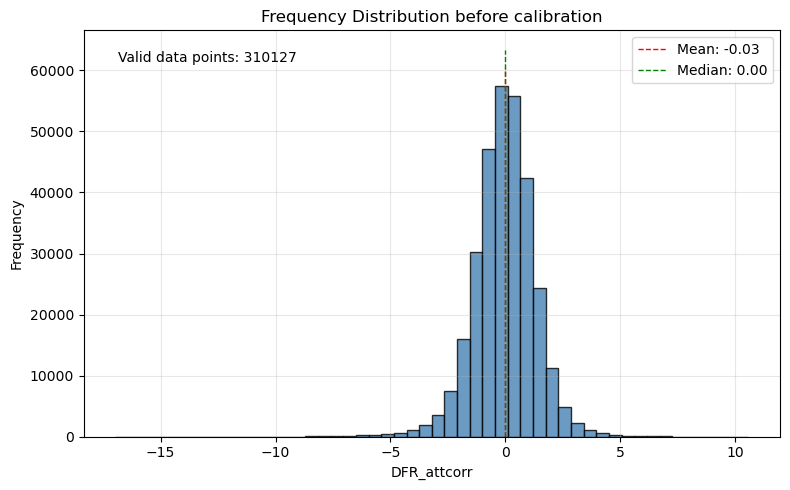

Plot saved to VAMP2_bef_dfr_distribution_offsetapplied.png


In [ ]:
#----------------------------------------------------------------------
# Plot the frequency distribution
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(dfr_bef, bins=N_BINS, color="steelblue", edgecolor="black", alpha=0.8)

ax.set_xlabel(f"{VARIABLE}")
ax.set_ylabel("Frequency")
ax.set_title(f"Frequency Distribution before calibration")
ax.grid(alpha=0.3)

plt.vlines(np.mean(dfr_bef), 0, ax.get_ylim()[1], color='red', linestyle='dashed', linewidth=1, label=f'Mean: {np.mean(dfr_bef):.2f}')
plt.vlines(np.median(dfr_bef), 0, ax.get_ylim()[1], color='green', linestyle='dashed', linewidth=1, label=f'Median: {np.median(dfr_bef):.2f}')
plt.legend()
plt.text(0.05, 0.95, f"Valid data points: {dfr_bef.size}", transform=ax.transAxes, fontsize=10, verticalalignment='top')

OUTPUT_PLOT = f"VAMP2_bef_dfr_distribution_offsetapplied.png"
plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=150)
plt.show()

print(f"Plot saved to {OUTPUT_PLOT}")

#ds.close()

In [ ]:
cmap = plt.cm.jet
cmaplist = [cmap(i) for i in range(cmap.N)]

cmap = mpl.colors.LinearSegmentedColormap.from_list(
    'Custom cmap', cmaplist, cmap.N)

bounds = np.linspace(0, 5, 6)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

/tmp/ipykernel_134219/1074157105.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  plt.scatter(dfr_aft, wze_aft, c='blue', s=1, vmin=-5, vmax=7, alpha=0.05, label='After Calibration')
/tmp/ipykernel_134219/1074157105.py:6: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  plt.scatter(dfr_bef, wze_bef, c='red', vmin=-5, s=1, vmax=7, alpha=0.05, label='Before Calibration')
/tmp/ipykernel_134219/1074157105.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_134219/1074157105.py:25: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(WG_scatterplot)


Scatter plot saved to VAMP2_before_after_calib_DFR_WZe_15cutoff_offsetapplied.png


lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


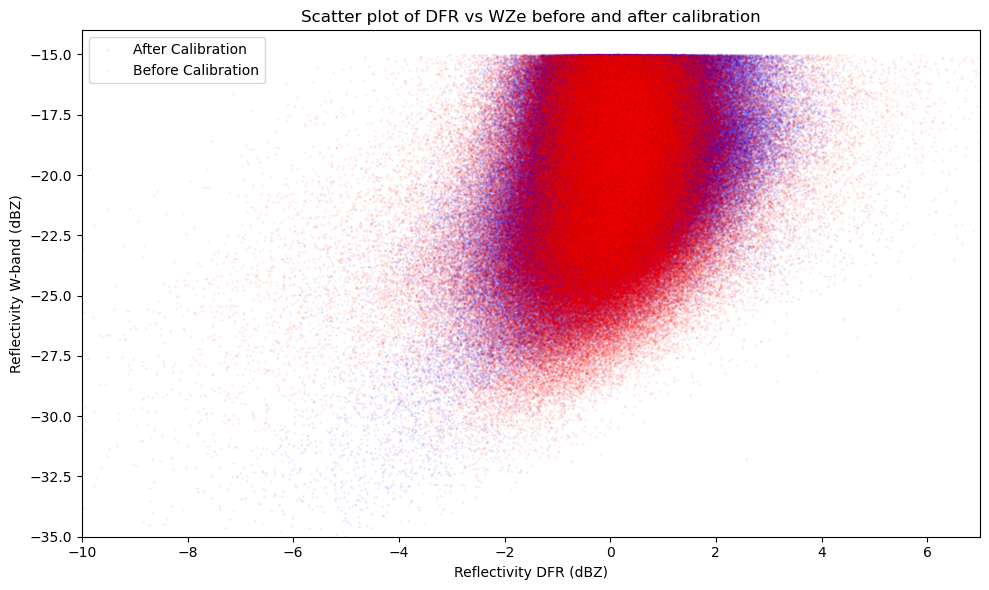

In [ ]:
# ---------------------------------------------------------------------
# Plot ZeW vs ZeG values in a scatter plot
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(dfr_aft, wze_aft, c='blue', s=1, vmin=-5, vmax=7, alpha=0.05, label='After Calibration')
plt.scatter(dfr_bef, wze_bef, c='red', vmin=-5, s=1, vmax=7, alpha=0.05, label='Before Calibration')
plt.title(f"Scatter plot of DFR vs WZe before and after calibration") #from {START_TIME} to {END_TIME}")
plt.xlabel(f"Reflectivity DFR (dBZ)")
plt.ylabel(f"Reflectivity W-band (dBZ)")
plt.legend()
plt.ylim(-35,-14)
plt.xlim(-10,7)
#plt.colorbar(label=f"Case number")
#plt.xticks(rotation=45)

#plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%H:%M'))
#plt.ylabel("Reflectivity (dB)")
#colorbar = plt.colorbar(label=f"{VARIABLE} (dB)")
#plt.grid(axis='y', alpha=0.75)
#plt.plot(np.arange(-45, -5), np.arange(-45, -5), color='black', linestyle='dashed', linewidth=1, label='1:1 line')
plt.tight_layout()


WG_scatterplot = f"VAMP2_before_after_calib_DFR_WZe_15cutoff_offsetapplied.png"
plt.savefig(WG_scatterplot)
print(f"Scatter plot saved to {WG_scatterplot}")

/tmp/ipykernel_134219/614540029.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
  plt.scatter(wze_bef, gze_bef, c='red', vmin=-5, s=1, vmax=7, alpha=0.03, label='Before Calibration')
/tmp/ipykernel_134219/614540029.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  plt.scatter(wze_aft, gze_aft, c='blue', cmap='viridis', vmin=-5, s=1, vmax=7, alpha=0.03, label='After Calibration')
/tmp/ipykernel_134219/614540029.py:26: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_134219/614540029.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"VAMP2_before_after_calib_tilt_LWP_rayleigh_histogram_offsetapplied.png")
/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of 

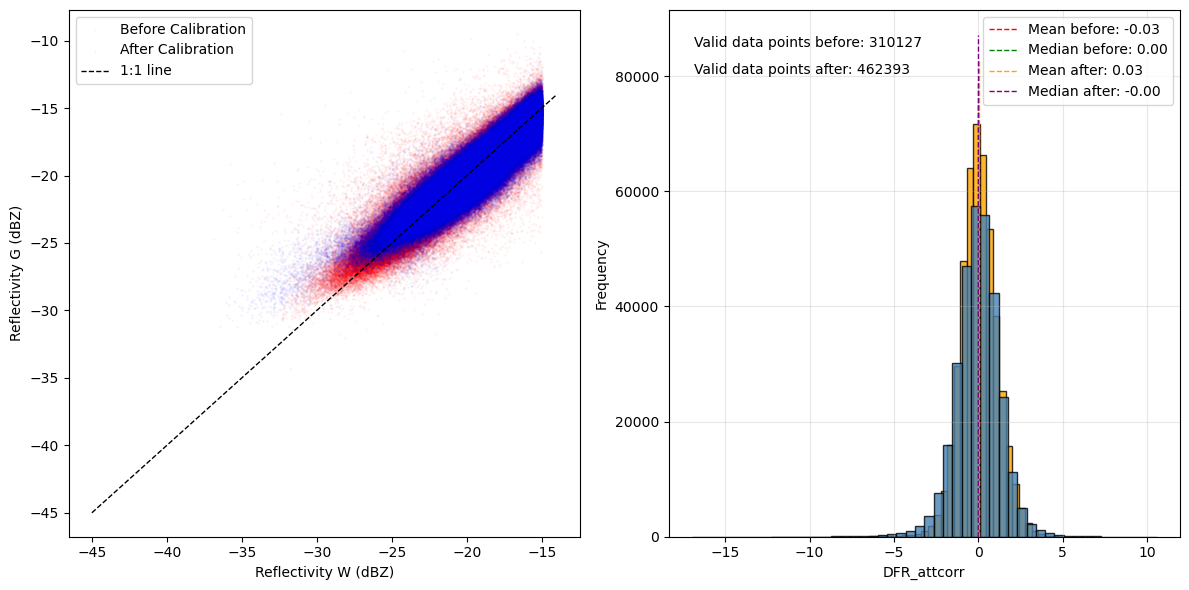

In [ ]:
# ---------------------------------------------------------------------
# Plot: scatter plot of WZe and GZe after and before calibration, with frequency distribution of DFR
# ---------------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(wze_bef, gze_bef, c='red', vmin=-5, s=1, vmax=7, alpha=0.03, label='Before Calibration')
plt.scatter(wze_aft, gze_aft, c='blue', cmap='viridis', vmin=-5, s=1, vmax=7, alpha=0.03, label='After Calibration')
#plt.title(f"ZeW vs ZeG before and after calibration") #from {START_TIME} to {END_TIME}")
plt.plot(np.arange(-45, -13), np.arange(-45, -13), color='black', linestyle='dashed', linewidth=1, label='1:1 line')
plt.xlabel(f"Reflectivity W (dBZ)")
plt.ylabel(f"Reflectivity G (dBZ)")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(dfr_aft, bins=N_BINS, color="orange", edgecolor="black", alpha=0.8)
plt.hist(dfr_bef, bins=N_BINS, color="steelblue", edgecolor="black", alpha=0.8)
plt.xlabel(f"{VARIABLE}")
plt.ylabel("Frequency")
#plt.title(f"Frequency Distribution of {VARIABLE}\n({START_TIME} to {END_TIME})")
plt.grid(alpha=0.3)
plt.vlines(np.mean(dfr_bef), 0, plt.gca().get_ylim()[1], color='red', linestyle='dashed', linewidth=1, label=f'Mean before: {np.mean(dfr_bef):.2f}')
plt.vlines(np.median(dfr_bef), 0, plt.gca().get_ylim()[1], color='green', linestyle='dashed', linewidth=1, label=f'Median before: {np.median(dfr_bef):.2f}')
plt.vlines(np.mean(dfr_aft), 0, plt.gca().get_ylim()[1], color='orange', linestyle='dashed', linewidth=1, label=f'Mean after: {np.mean(dfr_aft):.2f}')
plt.vlines(np.median(dfr_aft), 0, plt.gca().get_ylim()[1], color='purple', linestyle='dashed', linewidth=1, label=f'Median after: {np.median(dfr_aft):.2f}')
plt.legend()
plt.text(0.05, 0.95, f"Valid data points before: {dfr_bef.size}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.text(0.05, 0.90, f"Valid data points after: {dfr_aft.size}", transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
plt.tight_layout()
plt.savefig(f"VAMP2_before_after_calib_tilt_LWP_rayleigh_histogram_offsetapplied.png")

In [ ]:
lwc_all = xr.concat([lwc[i] for i in range(2, )], dim=TIME_DIM)

In [ ]:
# ---------------------------------------------------------------------
# lwc distribution plot: add lwps of each case to the histogram in different colors
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist([lwc[i]['clwvi'] for i in range(1, 5)], stacked=True, bins=N_BINS, color=["steelblue", "orange", "green", "red"], edgecolor="black", alpha=0.8)
plt.xlabel(f"LWC (kg/m²)")
plt.ylabel("Frequency")
plt.legend([f"{globals()['START_TIME' + str(i)][0:4]}-{globals()['START_TIME' + str(i)][5:7]}-{globals()['START_TIME' + str(i)][8:10]}" for i in range(1, 5)])
plt.title(f"Frequency Distribution of LWC during cirrus cases") #\n({START_TIME} to {END_TIME})")
plt.grid(alpha=0.3)
plt.savefig(f"VAMP1_LWP_histogram.png")

In [ ]:
# ---------------------------------------------------------------------
# lwp distribution plot colored by case number
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(lwc_all['clwvi']/1000, bins=N_BINS, color="steelblue", edgecolor="black", alpha=0.8)
plt.xlabel(f"LWC (g/m²)")
plt.ylabel("Frequency")
plt.title(f"Frequency Distribution of LWC\n({START_TIME} to {END_TIME})")
plt.grid(alpha=0.3)
#plt.savefig(f"VAMP1_before_after_calib_filtered_tilt_LWP_histogram.png")

In [5]:
dfr = ds_subset['DFR'].values
Ze = ds_subset['WZe'].values

In [6]:
bad_indices = np.isnan(Ze) | np.isnan(dfr)

Ze = Ze[~bad_indices]
dfr = dfr[~bad_indices]

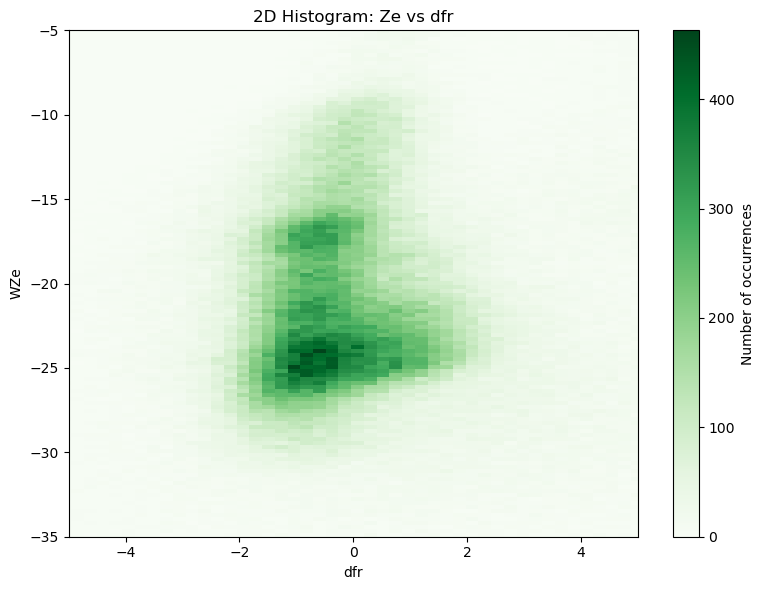

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

h = ax.hist2d(
    dfr.ravel(),
    Ze.ravel(),
    bins=200,
    cmap='Greens',
    #norm=plt.cm.LogNorm()  # logarithmic color scale helps when counts vary widely
)
ax.set_ylim([-35, -5])
ax.set_xlim([-5, 5])
colorbar = plt.colorbar(h[3], ax=ax, label='Number of occurrences')
#cb1=fig.colorbar(cay[3],label="count in bin")
ax.set_ylabel('WZe')
ax.set_xlabel('dfr')
ax.set_title('2D Histogram: Ze vs dfr')


plt.tight_layout()
plt.savefig(f"VAMP1_2D_histogram_Ze_dfr.png")
plt.show()
